# Heavy Equipment Selling Price Prediction using Machine Learning

## Kaggle Competition Project




The notebook follows a complete end-to-end machine learning workflow consisting of:

- Data Loading
- Exploratory Data Analysis (EDA)
- Data Quality Assessment
- Data Preprocessing
- Feature Engineering
- Train-Validation Split
- Model Development
- Hyperparameter Tuning
- Ensemble Learning
- Model Evaluation
- Final Submission Generation

The competition evaluates predictions using the **Root Mean Squared Logarithmic Error (RMSLE)** metric.

Since RMSLE measures errors on the logarithmic scale, the model is trained on **log1p(TargetValue)** (i.e., log(x+1) as lof(0) is not defined ) to maintain consistency between training and evaluation while reducing the impact of extremely expensive equipment.




## Experimental Integrity

The notebook follows good machine learning practices to ensure reliable model evaluation.

- The validation dataset is created before any preprocessing.
- Preprocessing statistics are learned only from the training partition.
- Competition test data is never used during model development.
- The sample submission file is used only to verify the required submission format.
- Validation RMSLE is used for model selection before generating the final submission.

These practices help produce an unbiased estimate of model performance and prevent information leakage.



# 1. Libraries and Competition Dataset import

In [1]:
'''---Library Imports---'''

import numpy as np
import pandas as pd

from pathlib import Path 
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

#defining constant so every model is equally traned and reproducability of result at every time
RANDOM_STATE = 42
TARGET = "TargetValue"
ID_COLUMN = "TransactionID"


print(f"Random State     : {RANDOM_STATE}")
print(f"Target Column    : {TARGET}")
print(f"ID Column        : {ID_COLUMN}")

Random State     : 42
Target Column    : TargetValue
ID Column        : TransactionID


In [2]:
#Basic data path, and shape analysis

train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")
metadata = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv")

print("Train-",train.shape)
print("\nTest-",test.shape)
print("\nSample submission-\n",sample_submission.head())
print(f"\n Metadata",metadata.head())

Train- (138701, 50)

Test- (15000, 49)

Sample submission-
    TransactionID  TargetValue
0        1139307      44674.9
1        1139419      91450.1
2        1139482      76618.1
3        1139522      75195.6
4        1139684       8340.3

 Metadata           Variable                              Rephrased Description
0    TransactionID  A unique serial number assigned to each indivi...
1      TargetValue  The financial amount of the transaction, denom...
2          AssetID  The internal tracking number assigned to a spe...
3  ProductConfigID  A system-generated code representing the techn...
4   DataOriginCode  A code indicating the specific software or pla...


| File | Purpose |
|------|---------|
| **train.csv** | Historical equipment records along with the target selling price |
| **test.csv** | Equipment records whose prices need to be predicted |
| **metadata.csv** | Description of every feature present in the dataset |
| **sample_submission.csv** | Required format for Kaggle submission |



# 2. Exploratory Data Analysis (EDA)


The objectives of EDA are:

- understand the distribution of the target variable,
- identify missing values,
- examine feature distributions,
- detect potential outliers,
- study relationships between important variables,
- understand feature cardinality,
- and generate insights that support feature engineering.




In [3]:
#Basic EDA

dates = pd.to_datetime(train['TransactionDate'], errors='coerce') 
print('Date range:', dates.min().date(), 'to', dates.max().date())

display(train[TARGET].describe().to_frame('TargetValue'))

Date range: 1990-01-31 to 2013-04-28


,TargetValue
count,138701.000000
mean,41521.874047
std,26361.125948
min,7500.000000
25%,20500.000000
50%,35000.000000
75%,57000.000000
max,142000.000000


### Univariate Analysis

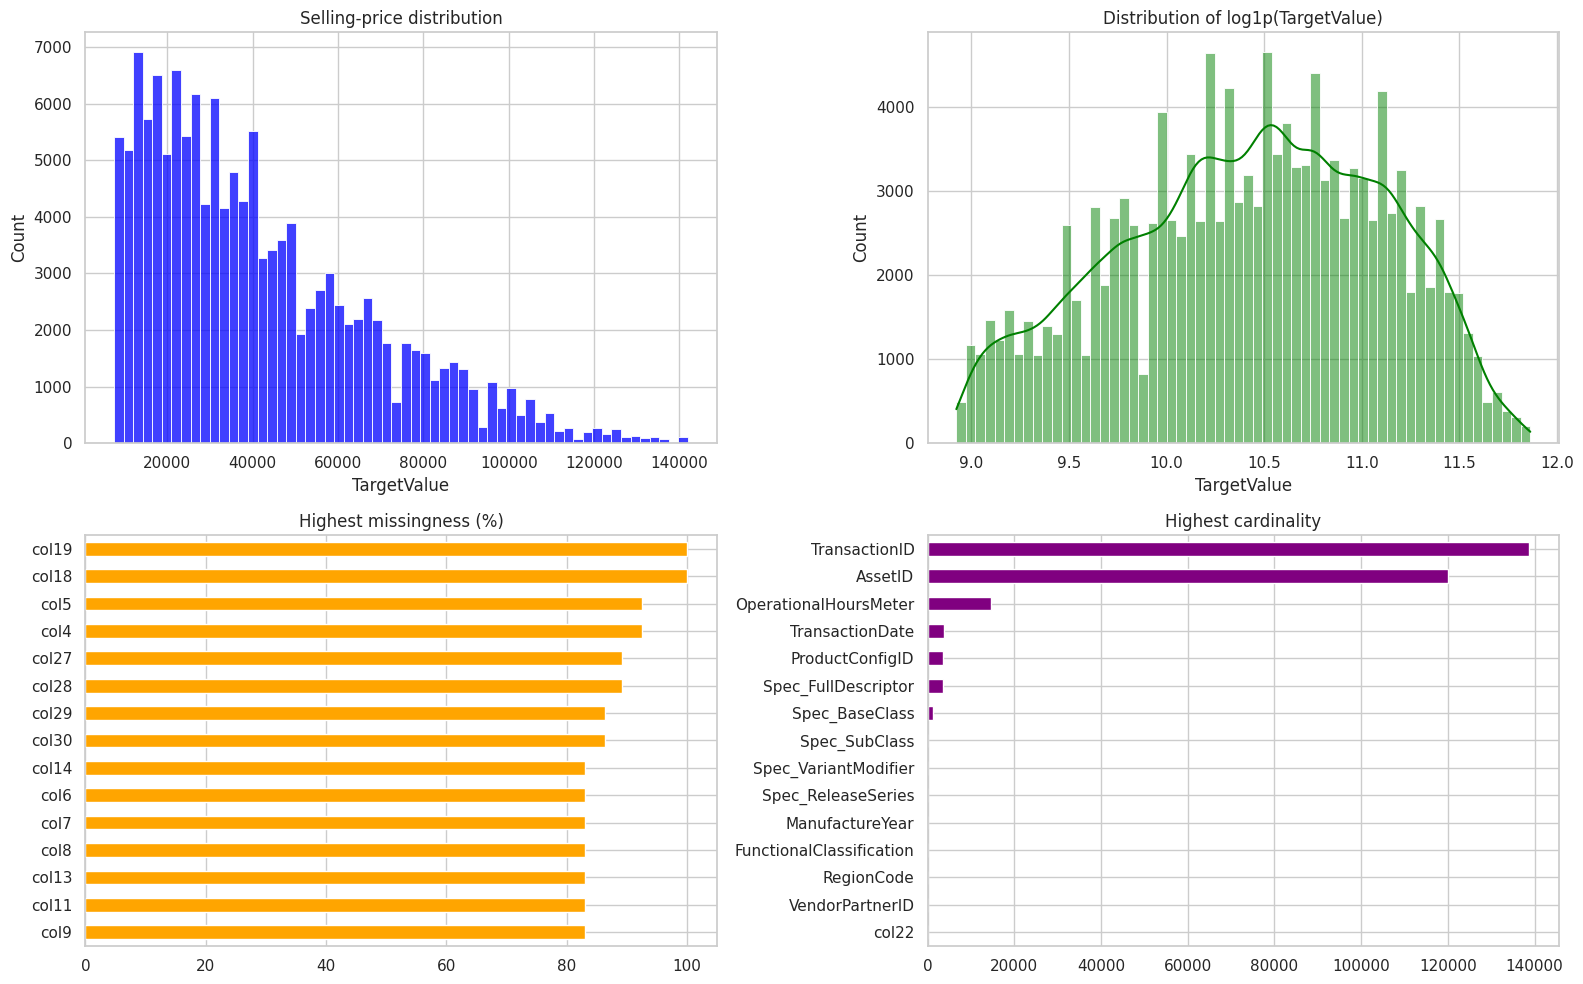

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

#U1-selling price frequency
sns.histplot(train[TARGET], bins=60, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Selling-price distribution')

#U2- log(1+TARGET) frequency
sns.histplot(np.log1p(train[TARGET]), bins=60, kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('Distribution of log1p(TargetValue)')


#U3- % missing values
missing = (100 * train.drop(columns=TARGET).isna().mean()).sort_values(ascending=False)
missing.head(15).sort_values().plot.barh(ax=axes[1, 0], color='orange', title='Highest missingness (%)')


#U4- Cardianality/uniqueness
cardinality = train.drop(columns=TARGET).nunique().sort_values(ascending=False)
cardinality.head(15).sort_values().plot.barh(ax=axes[1, 1], color='purple', title='Highest cardinality')


plt.tight_layout()
plt.show()



### Bivariate Analysis

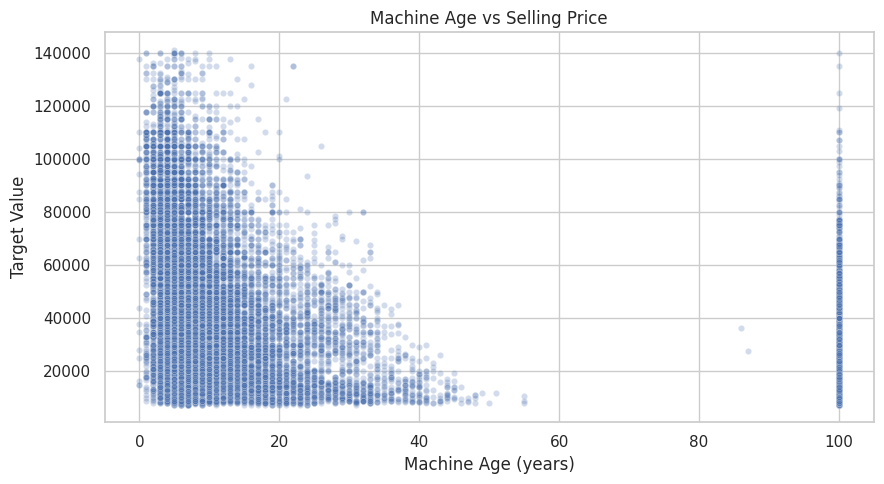

In [5]:
# B1- Relationship between machine-age and selling-price

eda_age = train[["TransactionDate","ManufactureYear",TARGET]].copy()

eda_age["TransactionDate"] = pd.to_datetime(eda_age["TransactionDate"],errors="coerce")

eda_age["TransactionYear"] = eda_age["TransactionDate"].dt.year

eda_age["MachineAge"] = (eda_age["TransactionYear"] - eda_age["ManufactureYear"]).clip(lower=0, upper=100)

age_plot = eda_age.dropna(subset=["MachineAge", TARGET]).sample(
    min(20000, len(eda_age.dropna(subset=["MachineAge", TARGET]))
       ),random_state=RANDOM_STATE)

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=age_plot,
    x="MachineAge",
    y=TARGET,
    alpha=0.25,
    s=20
)

plt.title("Machine Age vs Selling Price")
plt.xlabel("Machine Age (years)")
plt.ylabel("Target Value")

plt.tight_layout()
plt.show()


The observed pattern is not perfectly linear, but machine age provides useful information about equipment value. This motivates retaining the engineered `MachineAge` feature during model development.

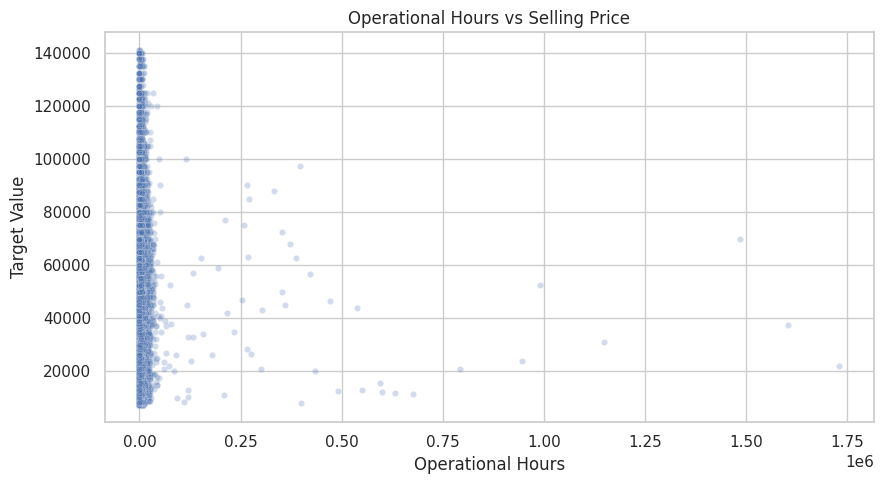

In [6]:
#B2- Relationship between operational-hours and selling-price

hours_plot = train[["OperationalHoursMeter", TARGET]].dropna()

hours_plot = hours_plot.sample(min(20000, len(hours_plot)),random_state=RANDOM_STATE)

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=hours_plot,
    x="OperationalHoursMeter",
    y=TARGET,
    alpha=0.25,
    s=20
)

plt.title("Operational Hours vs Selling Price")
plt.xlabel("Operational Hours")
plt.ylabel("Target Value")

plt.tight_layout()
plt.show()



Operational usage is examined because accumulated operating hours can provide information about equipment depreciation and condition.

The relationship shows substantial variation, indicating that operational hours alone are not sufficient to determine price, but the feature can provide useful complementary information to the model.

OperationalHoursMeter contains extreme values and substantial skewness, so blindly treating it as a normal numerical variable may not be ideal.

##  Key Findings from EDA

The exploratory analysis provides several important insights:

- The target variable is positively skewed, making logarithmic transformation appropriate for RMSLE optimization.
- Missing values are concentrated in a subset of equipment-related attributes and will be handled through a reusable preprocessing pipeline.
- Equipment manufacturing year and operational information appear informative for predicting selling price.
- Several categorical variables exhibit high cardinality, making LightGBM's native categorical handling an appropriate modeling choice.
- No major data quality issues were observed that would prevent model development.



# 3. Data Preprocessing & Feature Engineering

## 3.1 Train–Validation Split 

The dataset is divided before any preprocessing is performed.
This prepares the data for model training by:
- Separating features and target.
- Applying log transformation to the target.
- Creating bins for stratified sampling.
- Splitting the data into training and validation sets.
- Printing the split sizes.

**Split-**  

- **Training Partition:** Used for learning preprocessing rules and fitting machine learning models.
- **Validation Partition:** Used only for model evaluation and model selection.



In [7]:
#train=(Features + TargetValue)
raw_features = train.drop(columns=TARGET).copy() 

y_log = np.log1p(train[TARGET]).astype('float32')

strata = pd.qcut(y_log, q=20, duplicates='drop')

raw_fit, raw_valid, y_fit, y_valid = train_test_split(
    raw_features, y_log, test_size=0.20, random_state=RANDOM_STATE, stratify=strata )

print('Raw fit:', raw_fit.shape, '| Raw validation:', raw_valid.shape)

Raw fit: (110960, 49) | Raw validation: (27741, 49)


## 3.2 Custom Preprocessing Pipeline

Rather than performing preprocessing through scattered notebook cells, the entire
workflow is encapsulated inside a reusable preprocessing class.


In [8]:
"""
Reusable preprocessing pipeline -
1. Remove columns containing almost entirely missing values.
2. Extract useful temporal information from transaction dates.
3. Engineer machine age.
4. Standardize categorical representations.
5. Produce identical feature spaces for training,validation and competition test datasets.

The fit() method learns preprocessing decisions only from the training partition.

The transform() method applies those decisions without accessing target values or validation information,
thereby preventing data leakage.
""" 

class HeavyEquipmentPreprocessor:
    
    def __init__(self, missing_threshold=0.995): 
        self.missing_threshold = missing_threshold

    def fit(self, frame):
        self.drop_columns_ = frame.isna().mean().loc[lambda s: s >= self.missing_threshold].index.tolist()
        self.input_columns_ = [c for c in frame.columns if c not in self.drop_columns_]
        return self

    
    def transform(self, frame):
        x = frame.reindex(columns=self.input_columns_).copy()
        dt = pd.to_datetime(x['TransactionDate'], errors='coerce')

        #custom features
        x['TransactionYear'] = dt.dt.year
        x['TransactionMonth'] = dt.dt.month
        x['TransactionQuarter'] = dt.dt.quarter
        x['TransactionDayOfWeek'] = dt.dt.dayofweek
        x['TransactionDayOfYear'] = dt.dt.dayofyear
        x['MachineAge'] = (x['TransactionYear'] - x['ManufactureYear']).clip(lower=0, upper=100)
        hours = x['OperationalHoursMeter'].clip(lower=0)
        x['OperationalHoursLog'] = np.log1p(hours)
        x['HoursPerYear'] = (hours / (x['MachineAge'] + 1)).replace([np.inf, -np.inf], np.nan)
        descriptor = x['Spec_FullDescriptor'].fillna('').astype(str)
        x['DescriptorLength'] = descriptor.str.len()
        x['DescriptorDigitCount'] = descriptor.str.count(r'\d')
        x['DescriptorLetterCount'] = descriptor.str.count(r'[A-Za-z]')
        x['RowMissingCount'] = x.isna().sum(axis=1)
        x = x.drop(columns='TransactionDate')

        
        for col in x.select_dtypes(include=['object', 'category']).columns:
            x[col] = x[col].fillna('__MISSING__').astype(str)
        return x


def lightgbm_categories(x_fit, x_other):
    x_fit, x_other = x_fit.copy(), x_other.copy()
    cats = x_fit.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cats:
        dtype = pd.CategoricalDtype(categories=pd.Index(x_fit[col].astype(str).unique()))
        x_fit[col] = x_fit[col].astype(str).astype(dtype)
        x_other[col] = x_other[col].astype(str).astype(dtype)
    return x_fit, x_other, cats

## 3.3 Feature Engineering


The preprocessing pipeline creates several additional variables automatically.

**Transaction Year -**
This feature captures long-term market trends because equipment values vary over time.

**Transaction Month-**
Captures seasonal effects in equipment auctions.

**Transaction Quarter-**
Represents broader seasonal purchasing behaviour.

**Transaction Day of Week-**
Allows the model to learn any weekly auction patterns.

**Machine Age-**
Rather than using manufacturing year directly, machine age is computed.
Machine age is generally more informative because depreciation depends on how old the
equipment is at the time of sale rather than on its manufacturing year alone.

In [9]:
preprocessor = HeavyEquipmentPreprocessor().fit(raw_fit)

X_fit = preprocessor.transform(raw_fit)

X_valid = preprocessor.transform(raw_valid)

X_fit, X_valid, categorical_features = lightgbm_categories(X_fit, X_valid)

print('Dropped for extreme missingness:', preprocessor.drop_columns_)
print('Model features:', X_fit.shape[1], '| Categorical features:', len(categorical_features))
assert list(X_fit.columns) == list(X_valid.columns)

Dropped for extreme missingness: ['col18', 'col19']
Model features: 58 | Categorical features: 41


## 3.4 Preprocessing Results



The preprocessing stage performs the following operations:

- removes features containing almost no usable information,
- generates temporal features,
- computes machine age,
- converts categorical variables into an efficient representation for LightGBM,
- preserves identical feature ordering across all datasets.


# 4. Model Development

Objectives:

1. Create a LightGBM model.
2. Train it on the training data.
3. Monitor its performance on the validation data.
4. Stop training automatically if it stops improving.
5. Evaluate the final model using RMSLE.

## 4.1 Baseline LightGBM Model

LightGBM (Light Gradient Boosting Machine) is selected as the primary learning algorithm because it consistently performs well on structured tabular datasets.

During training, early stopping is enabled. Validation performance is monitored after every boosting iteration, and training automatically terminates once additional trees no longer improve validation accuracy.

This prevents unnecessary model complexity while reducing the likelihood of overfitting.

In [10]:
validation_model = lgb.LGBMRegressor(
    objective='regression', n_estimators=5000, learning_rate=0.03,
    num_leaves=63, 
    min_child_samples=35, 
    colsample_bytree=0.90, 
    reg_lambda=1.0,
    random_state=RANDOM_STATE, 
    n_jobs=-1, 
    verbosity=-1 
)



validation_model.fit(
    X_fit, y_fit, categorical_feature=categorical_features,
    eval_set=[(X_valid, y_valid)], eval_metric='rmse',
    callbacks=[lgb.early_stopping(200, verbose=True), lgb.log_evaluation(250)],
)

valid_prediction_log = validation_model.predict(X_valid, num_iteration=validation_model.best_iteration_)
valid_rmsle = root_mean_squared_error(y_valid, valid_prediction_log)


print(f'Best iteration: {validation_model.best_iteration_}')
print(f'Leakage-safe validation RMSLE: {valid_rmsle:.5f}')

Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 0.217923	valid_0's l2: 0.0474905
[500]	valid_0's rmse: 0.210683	valid_0's l2: 0.0443874
[750]	valid_0's rmse: 0.208214	valid_0's l2: 0.0433531
[1000]	valid_0's rmse: 0.206977	valid_0's l2: 0.0428396
[1250]	valid_0's rmse: 0.206146	valid_0's l2: 0.0424962
[1500]	valid_0's rmse: 0.205535	valid_0's l2: 0.0422445
[1750]	valid_0's rmse: 0.205064	valid_0's l2: 0.0420514
[2000]	valid_0's rmse: 0.204689	valid_0's l2: 0.0418976
[2250]	valid_0's rmse: 0.204406	valid_0's l2: 0.041782
[2500]	valid_0's rmse: 0.204216	valid_0's l2: 0.0417044
[2750]	valid_0's rmse: 0.203993	valid_0's l2: 0.041613
[3000]	valid_0's rmse: 0.203795	valid_0's l2: 0.0415326
[3250]	valid_0's rmse: 0.203685	valid_0's l2: 0.0414878
[3500]	valid_0's rmse: 0.203549	valid_0's l2: 0.0414322
[3750]	valid_0's rmse: 0.203463	valid_0's l2: 0.0413972
[4000]	valid_0's rmse: 0.203375	valid_0's l2: 0.0413613
[4250]	valid_0's rmse: 0.20329	valid_0's l2: 0.

## 4.2 Baseline Model Evaluation

The baseline LightGBM model was evaluated on the validation
partition to estimate its generalization performance.

Since preprocessing decisions were learned exclusively from
the training partition, the reported RMSLE provides an
unbiased estimate of model performance.



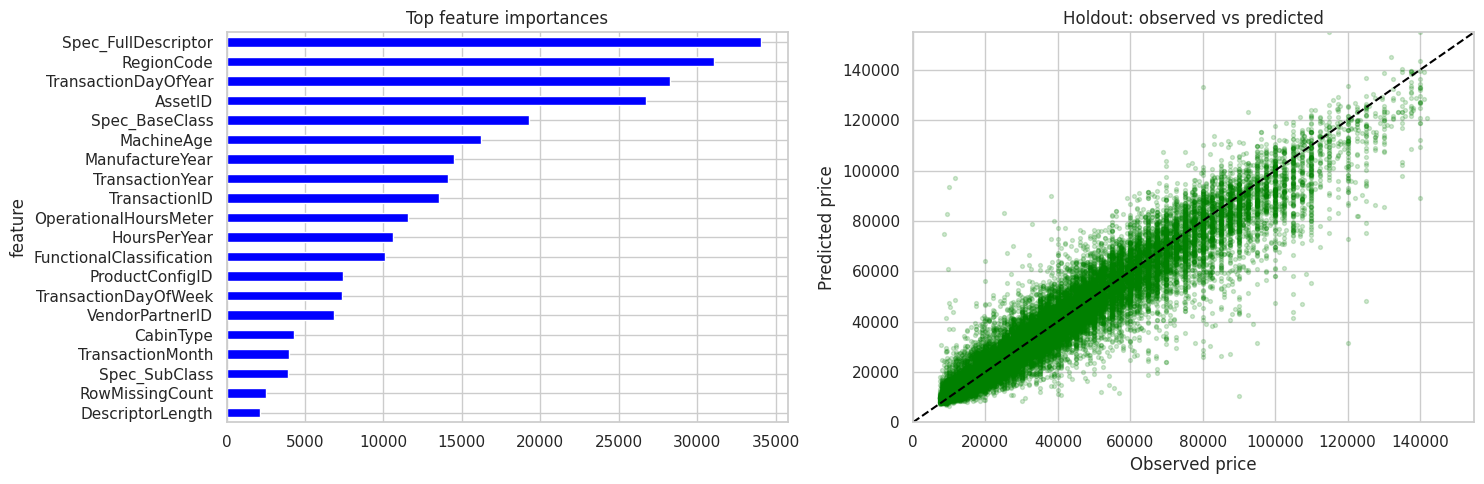

,feature,importance
8,Spec_FullDescriptor,34051
15,RegionCode,31076
50,TransactionDayOfYear,28291
1,AssetID,26756
9,Spec_BaseClass,19288
51,MachineAge,16201
5,ManufactureYear,14484
46,TransactionYear,14147
0,TransactionID,13537
6,OperationalHoursMeter,11562


In [11]:

#importance score of every feature.
importance = pd.DataFrame({'feature': X_fit.columns, 'importance': validation_model.feature_importances_}).sort_values('importance', ascending=False)

valid_actual = np.expm1(y_valid.to_numpy())

valid_prediction = np.clip(np.expm1(valid_prediction_log), 0, None)

#Creating figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

importance.head(20).sort_values('importance').plot.barh(x='feature', y='importance', legend=False, ax=axes[0], color='blue')
axes[0].set_title('Top feature importances')


axes[1].scatter(valid_actual, valid_prediction, s=8, alpha=0.18, color='green')

limit = max(valid_actual.max(), valid_prediction.max())

axes[1].plot([0, limit], [0, limit], '--', color='black')#line on scatter plot
axes[1].set(xlim=(0, limit), ylim=(0, limit), title='Holdout: observed vs predicted', xlabel='Observed price', ylabel='Predicted price')
plt.tight_layout()
plt.show()

display(importance.head(25))

### Interpretation


- `Spec_FullDescriptor` is the most influential feature, suggesting that
detailed machine specifications play the largest role in determining
market value. `RegionCode` ranks second, indicating that regional
market conditions also have a significant impact on resale prices. `TransactionDayOfYear` is highly important, suggesting that seasonal
or time-related effects influence auction outcomes.

- Engineered features such as `MachineAge`, `HoursPerYear`, and
`TransactionYear` also contribute substantially, confirming that the feature engineering process successfully extracted meaningful information from the original dataset.

- The observed-versus-predicted scatter plot shows that most predictions
closely follow the ideal diagonal, indicating good overall predictive
performance.

- A larger spread is visible for high-value equipment,
suggesting that the model finds very expensive machines more difficult
to predict accurately due to greater variability.

## 4.3 Regularized LightGBM

Although the baseline model performs well, gradient boosting
models may still overfit when tree complexity becomes high.

To investigate whether stronger regularization improves
generalization, a second LightGBM model is trained using
additional regularization parameters while keeping the
preprocessing pipeline unchanged.


In [12]:
# Regularized LightGBM Model
regularized_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=5000,
    learning_rate=0.03,

    # Stronger regularization than the baseline model
    num_leaves=31,
    min_child_samples=60,
    colsample_bytree=0.80,
    reg_lambda=5.0,
    reg_alpha=1.0,

    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)


regularized_model.fit(
    X_fit,
    y_fit,
    categorical_feature=categorical_features,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(200, verbose=True),
        lgb.log_evaluation(250),
    ],
)

# Validation Predictions
regularized_prediction_log = regularized_model.predict(
    X_valid,
    num_iteration=regularized_model.best_iteration_,
)

# Validation RMSLE
regularized_rmsle = root_mean_squared_error(
    y_valid,
    regularized_prediction_log,
)




Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 0.225736	valid_0's l2: 0.0509567
[500]	valid_0's rmse: 0.215881	valid_0's l2: 0.0466047
[750]	valid_0's rmse: 0.212614	valid_0's l2: 0.0452048
[1000]	valid_0's rmse: 0.210585	valid_0's l2: 0.0443462
[1250]	valid_0's rmse: 0.209314	valid_0's l2: 0.0438125
[1500]	valid_0's rmse: 0.208368	valid_0's l2: 0.0434172
[1750]	valid_0's rmse: 0.207652	valid_0's l2: 0.0431193
[2000]	valid_0's rmse: 0.207042	valid_0's l2: 0.0428664
[2250]	valid_0's rmse: 0.206557	valid_0's l2: 0.042666
[2500]	valid_0's rmse: 0.206144	valid_0's l2: 0.0424954
[2750]	valid_0's rmse: 0.20577	valid_0's l2: 0.0423411
[3000]	valid_0's rmse: 0.205437	valid_0's l2: 0.0422042
[3250]	valid_0's rmse: 0.205174	valid_0's l2: 0.0420964
[3500]	valid_0's rmse: 0.20492	valid_0's l2: 0.0419922
[3750]	valid_0's rmse: 0.204722	valid_0's l2: 0.0419109
[4000]	valid_0's rmse: 0.204533	valid_0's l2: 0.0418339
[4250]	valid_0's rmse: 0.204367	valid_0's l2: 0.

## 4.4 Regularized Model Evaluation

- The regularized model is compared with the baseline model.

- If validation performance improves, it indicates that the
additional regularization successfully reduced overfitting.

- Otherwise, the baseline configuration remains preferable.

In [13]:
# Regularized LightGBM Evaluation

# Compare validation performance with the baseline model
comparison = pd.DataFrame({
    "Model": [
        "Baseline LightGBM",
        "Regularized LightGBM"
    ],
    "Validation RMSLE": [
        valid_rmsle,
        regularized_rmsle
    ]
})

display(comparison)

# Improvement Analysis

difference = valid_rmsle - regularized_rmsle

print("Regularized LightGBM Evaluation")

print(f"Baseline LightGBM RMSLE    : {valid_rmsle:.5f}")
print(f"Regularized LightGBM RMSLE : {regularized_rmsle:.5f}")

if difference > 0:
    print(f"\n Regularization improved validation performance by {difference:.5f} RMSLE.")
elif difference < 0:
    print(f"\n Regularization reduced validation performance by {abs(difference):.5f} RMSLE.")
else:
    print("\n Both models achieved identical validation performance.")

,Model,Validation RMSLE
0,Baseline LightGBM,0.203192
1,Regularized LightGBM,0.203984


Regularized LightGBM Evaluation
Baseline LightGBM RMSLE    : 0.20319
Regularized LightGBM RMSLE : 0.20398

 Regularization reduced validation performance by 0.00079 RMSLE.


# 5. Alternative Learning Algorithm

## 5.1 Extra Trees Regressor

- While LightGBM is a gradient boosting algorithm, it is beneficial to
evaluate a fundamentally different ensemble method.

- Extra Trees (Extremely Randomized Trees) is selected because it builds
an ensemble of highly randomized decision trees using bagging rather
than boosting.

- Unlike LightGBM, where each tree attempts to correct the errors of the
previous trees, Extra Trees constructs trees independently using random
feature selection and random split thresholds.

- Although its standalone predictive performance may be lower than
LightGBM, its different learning strategy often produces complementary
prediction patterns, making it an excellent candidate for ensemble
learning.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder


X_tree_fit = preprocessor.transform(raw_fit)
X_tree_valid = preprocessor.transform(raw_valid)

tree_categorical = X_tree_fit.select_dtypes(include=['object', 'category']).columns.tolist()
tree_numeric = [column for column in X_tree_fit.columns if column not in tree_categorical]

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', SimpleImputer(strategy='median'), tree_numeric),
        ('categorical', make_pipeline(
            SimpleImputer(strategy='most_frequent'),
            OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1),
        ), tree_categorical),
    ],
    sparse_threshold=0,
)
X_tree_fit_ready = tree_preprocessor.fit_transform(X_tree_fit)
X_tree_valid_ready = tree_preprocessor.transform(X_tree_valid)

extra_trees_model = ExtraTreesRegressor(
    n_estimators=400, max_features=0.85, min_samples_leaf=1,
    random_state=RANDOM_STATE, n_jobs=-1,
)
extra_trees_model.fit(X_tree_fit_ready, y_fit)
tree_valid_prediction_log = extra_trees_model.predict(X_tree_valid_ready)


Unlike LightGBM: No boosting, No early stopping, No validation monitoring

It simply builds 400 randomized decision trees.

## 5.2 Extra Trees Evaluation

The validation RMSLE of the Extra Trees model is compared
against the LightGBM models developed earlier.

Although its standalone performance may be lower,
the different prediction behaviour makes it valuable
for ensemble learning.

In [15]:
tree_rmsle = root_mean_squared_error(
    y_valid,
    tree_valid_prediction_log
)
print(f"Extra Trees RMSLE  : {tree_rmsle:.5f}")

Extra Trees RMSLE  : 0.21988


# 6 Model Comparison

                          Model  Validation RMSLE
              Baseline LightGBM          0.203192
           Regularized LightGBM          0.203984
                    Extra Trees          0.219877
LightGBM + Extra Trees Ensemble          0.200180

Best Model:
LightGBM + Extra Trees Ensemble
Best Validation RMSLE:
0.20018


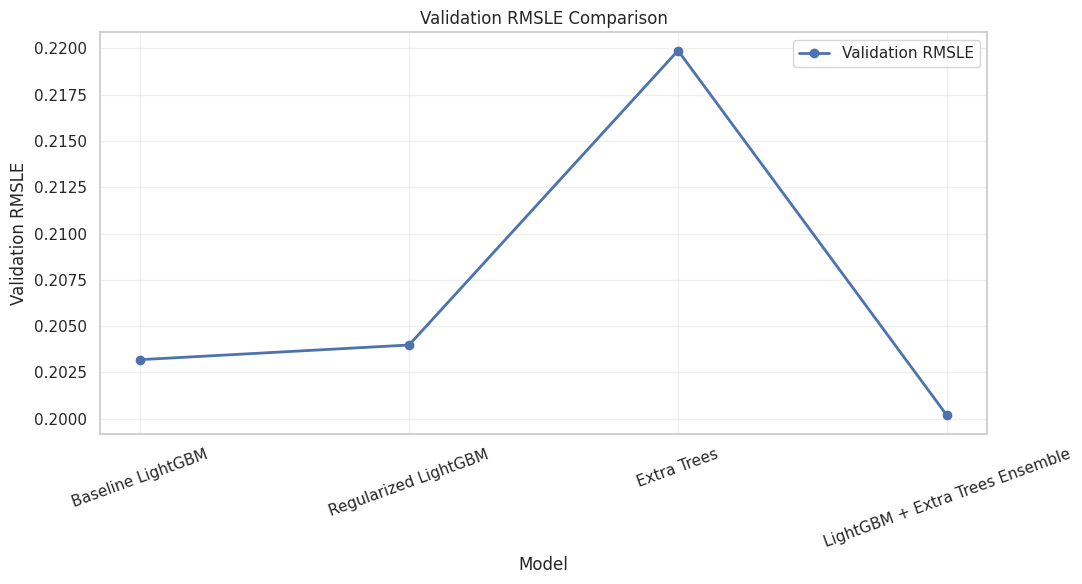

In [16]:

# MODEL PERFORMANCE COMPARISON

import pandas as pd
import matplotlib.pyplot as plt

# Store model results
model_results = pd.DataFrame({
    "Model": [
        "Baseline LightGBM",
        "Regularized LightGBM",
        "Extra Trees",
        "LightGBM + Extra Trees Ensemble"
    ],
    "Validation RMSLE": [
        0.203192,
        0.203984,
        0.219877,
        0.200180
    ]
})

# Display results
print(model_results.to_string(index=False))

# Find best model
best_model = model_results.loc[
    model_results["Validation RMSLE"].idxmin()
]

print("\nBest Model:")
print(best_model["Model"])

print("Best Validation RMSLE:")
print(best_model["Validation RMSLE"])

# Plot
plt.figure(figsize=(11, 6))

plt.plot(
    model_results["Model"],
    model_results["Validation RMSLE"],
    marker="o",
    linewidth=2,
    label="Validation RMSLE"
)

plt.xlabel("Model")
plt.ylabel("Validation RMSLE")
plt.title("Validation RMSLE Comparison")

plt.xticks(rotation=20)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 7 Ensemble Learning
Different models make different mistakes. Combining them can reduce the overall error

## 7.1 Model ensembling (blending)

Individual models often make different prediction errors.

Rather than selecting a single model, predictions from
LightGBM and Extra Trees are blended using different
candidate weights.

The weight producing the lowest validation RMSLE is
selected for the final ensemble.

In [17]:
# Evaluate several blend weights on the validation dataset.
candidate_weights = [0.50, 0.60, 0.70, 0.75, 0.80, 0.90]

blend_results = []

for weight in candidate_weights:
    blended_prediction = (
        weight * valid_prediction_log
        + (1 - weight) * tree_valid_prediction_log
    )

    rmsle = root_mean_squared_error(y_valid, blended_prediction)

    blend_results.append(
        {
            "LightGBM Weight": weight,
            "Extra Trees Weight": round(1 - weight, 2),
            "Validation RMSLE": rmsle,
        }
    )

blend_results = (
    pd.DataFrame(blend_results)
    .sort_values("Validation RMSLE")
    .reset_index(drop=True)
)

print("\nValidation Blend Weight Comparison")
print(blend_results.to_string(index=False))

BLEND_LIGHTGBM_WEIGHT = blend_results.loc[0, "LightGBM Weight"]
BLEND_EXTRA_TREES_WEIGHT = blend_results.loc[0, "Extra Trees Weight"]

print("\nSelected Ensemble Weights")
print(f"LightGBM   : {BLEND_LIGHTGBM_WEIGHT:.2f}")
print(f"Extra Trees: {BLEND_EXTRA_TREES_WEIGHT:.2f}")


Validation Blend Weight Comparison
 LightGBM Weight  Extra Trees Weight  Validation RMSLE
            0.70                0.30          0.200180
            0.75                0.25          0.200191
            0.80                0.20          0.200399
            0.60                0.40          0.200754
            0.90                0.10          0.201407
            0.50                0.50          0.202112

Selected Ensemble Weights
LightGBM   : 0.70
Extra Trees: 0.30


## 7.2 Ensemble Evaluation

Validation results show that the ensemble achieves a lower
prediction error than the individual models.

The best-performing blending weight is selected for the
final competition model.

In [18]:
model_results = pd.DataFrame({
    "Model": [
        "Baseline LightGBM",
        "Regularized LightGBM",
        "Extra Trees",
        "LightGBM + Extra Trees Ensemble"
    ],
    "Validation RMSLE": [
        valid_rmsle,
        regularized_rmsle,
        tree_rmsle,
        blend_results.loc[0, "Validation RMSLE"]
    ]
})

model_results = (
    model_results
    .sort_values("Validation RMSLE")
    .reset_index(drop=True)
)


print("Validation Performance Comparison")

display(model_results)

best_model = model_results.iloc[0]

print("\nBest Performing Model")
print(f"Model : {best_model['Model']}")
print(f"RMSLE : {best_model['Validation RMSLE']:.5f}")

Validation Performance Comparison


,Model,Validation RMSLE
0,LightGBM + Extra Trees Ensemble,0.200180
1,Baseline LightGBM,0.203192
2,Regularized LightGBM,0.203984
3,Extra Trees,0.219877



Best Performing Model
Model : LightGBM + Extra Trees Ensemble
RMSLE : 0.20018


# 8 Final Model Traning

## 8.1 Final LightGBM Training

After selecting the final model configuration using the validation
dataset, the LightGBM model is retrained using the complete labelled
training dataset.

Using all available observations enables the model to learn from the
entire dataset before making predictions on the competition test set.

The number of boosting iterations is determined from the best
validation iteration obtained earlier.

In [19]:
final_preprocessor = HeavyEquipmentPreprocessor().fit(raw_features)

X_full = final_preprocessor.transform(raw_features)
X_test = final_preprocessor.transform(test.copy())

X_full, X_test, final_categories = lightgbm_categories(X_full, X_test)

final_iterations = max(100, int(validation_model.best_iteration_ * 1.05))

final_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=final_iterations,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=35,
    colsample_bytree=0.90,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)

final_model.fit(
    X_full,
    y_log,
    categorical_feature=final_categories
)

predictions = np.clip(
    np.expm1(final_model.predict(X_test)),
    0,
    None
)

## 8.2 Final Extra Trees Training

Since the final submission uses an ensemble of LightGBM and Extra
Trees, the Extra Trees model is also retrained using the complete
training dataset.

The same preprocessing pipeline developed during validation is applied
before generating predictions for the competition test data.

In [20]:
X_tree_full = final_preprocessor.transform(raw_features)

X_tree_test = final_preprocessor.transform(test.copy())

X_tree_full_ready = tree_preprocessor.fit_transform(X_tree_full)

X_tree_test_ready = tree_preprocessor.transform(X_tree_test)

final_extra_trees_model = ExtraTreesRegressor(
    n_estimators=400,
    max_features=0.85,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_extra_trees_model.fit(
    X_tree_full_ready,
    y_log
)

tree_test_prediction = final_extra_trees_model.predict(
    X_tree_test_ready
)

# 9 Competition Submission

The final competition predictions are generated by combining the
LightGBM and Extra Trees predictions using the optimal blending
weight selected during validation.

The resulting ensemble predictions are converted back to the original
selling-price scale and exported as the final competition submission.

In [21]:
ensemble_test_prediction = np.clip(
    np.expm1(
        BLEND_LIGHTGBM_WEIGHT * np.log1p(predictions)
        + (1 - BLEND_LIGHTGBM_WEIGHT) * tree_test_prediction
    ),
    0,
    None,
)

ensemble_submission = pd.DataFrame({
    ID_COLUMN: test[ID_COLUMN].to_numpy(),
    TARGET: ensemble_test_prediction,
})

out_path = Path("/kaggle/working/new_ML_project_submission.csv")

ensemble_submission.to_csv(out_path, index=False)

assert ensemble_submission[ID_COLUMN].equals(test[ID_COLUMN])
assert ensemble_submission[TARGET].notna().all()
assert (ensemble_submission[TARGET] >= 0).all()

print(f"Validated ensemble submission saved: {out_path.resolve()}")

display(ensemble_submission.head())

Validated ensemble submission saved: /kaggle/working/new_ML_project_submission.csv


,TransactionID,TargetValue
0,1139307,63667.742667
1,1139419,78592.402866
2,1139482,31236.894243
3,1139522,21633.239695
4,1139684,12469.803182


# 10. Final Results & summary

The workflow included:

- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Leakage-safe preprocessing pipelines
- Model development
- Model comparison
- Ensemble learning
- Final competition submission

Every preprocessing transformation was fitted exclusively on the training partition before being applied to the validation and competition datasets. This ensured that the evaluation remained reproducible and free from data leakage.

In [22]:
# Final Model Performance Summary

print("FINAL MODEL PERFORMANCE SUMMARY")
performance_summary = pd.DataFrame({
    "Model": [
        "Baseline LightGBM",
        "Regularized LightGBM",
        "Extra Trees",
        "LightGBM + Extra Trees Ensemble"
    ],
    "Validation RMSLE": [
        valid_rmsle,
        regularized_rmsle,
        tree_rmsle,
        blend_results.loc[0, "Validation RMSLE"]
    ]
})

performance_summary = (
    performance_summary
    .sort_values("Validation RMSLE")
    .reset_index(drop=True)
)

display(performance_summary)

best_model = performance_summary.iloc[0]

print("\nBest Validation Model")
print(f"Model : {best_model['Model']}")
print(f"Validation RMSLE : {best_model['Validation RMSLE']:.5f}")

print("\nSelected Ensemble Weights")
print(f"LightGBM Weight   : {BLEND_LIGHTGBM_WEIGHT:.2f}")
print(f"Extra Trees Weight: {1 - BLEND_LIGHTGBM_WEIGHT:.2f}")

print("\nCompetition Submission")
print(f"Rows Submitted : {len(ensemble_submission)}")
print(f"Submission File: {out_path.resolve()}")

print("\nSubmission Statistics")
print(f"Minimum Prediction : {ensemble_submission[TARGET].min():,.2f}")
print(f"Maximum Prediction : {ensemble_submission[TARGET].max():,.2f}")
print(f"Average Prediction : {ensemble_submission[TARGET].mean():,.2f}")


FINAL MODEL PERFORMANCE SUMMARY


,Model,Validation RMSLE
0,LightGBM + Extra Trees Ensemble,0.200180
1,Baseline LightGBM,0.203192
2,Regularized LightGBM,0.203984
3,Extra Trees,0.219877



Best Validation Model
Model : LightGBM + Extra Trees Ensemble
Validation RMSLE : 0.20018

Selected Ensemble Weights
LightGBM Weight   : 0.70
Extra Trees Weight: 0.30

Competition Submission
Rows Submitted : 15000
Submission File: /kaggle/working/new_ML_project_submission.csv

Submission Statistics
Minimum Prediction : 7,561.14
Maximum Prediction : 139,193.65
Average Prediction : 40,781.76


In [23]:
# Kaggle Competition Result 
#Manual Entry

PUBLIC_LEADERBOARD_RMSLE = 0.19450   # Replace with your actual score
print("KAGGLE COMPETITION RESULT")
print(f"Public Leaderboard RMSLE : {PUBLIC_LEADERBOARD_RMSLE:.5f}")

KAGGLE COMPETITION RESULT
Public Leaderboard RMSLE : 0.19450
